# PrediCasa – Entregable I: Análisis exploratorio de datos
**Modelos y Simulación de Sistemas II – Universidad de Antioquia**

Dataset: *House Prices – Advanced Regression Techniques* (Kaggle), basado en Ames Housing (De Cock, 2011).

Tarea: **aprendizaje supervisado – regresión.**

**Equipo:** Roller Andrés Hernández López · Juan Miguel Cadena Zúñiga · Juan Felipe Martínez Patiño

**Antes de ejecutar:** Ver README.

## 0. Configuración

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

os.makedirs("figures", exist_ok=True)
SEED = 42

## 1. Carga de datos
Importante: en este dataset el texto `NA` **no** es un dato perdido en la mayoría de columnas categóricas, sino *ausencia de la característica* (sin piscina, sin garaje, sin sótano…).
Por eso se lee con `keep_default_na=False` y solo se marca `NA` como nulo, para que pandas no convierta también valores legítimos como `None` (p. ej. `MasVnrType = None`).

In [23]:
PATH = next((p for p in ["data/train.csv", "train.csv"] if os.path.exists(p)), None)
if PATH is None:
    raise FileNotFoundError("No se encontró train.csv. Descárgalo de Kaggle y colócalo en data/train.csv (ver README).")
print("Leyendo:", PATH)
df = pd.read_csv(PATH, keep_default_na=False, na_values=["NA", ""])
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Leyendo: train.csv
Dimensiones (filas, columnas): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Visión general

In [24]:
n_num = df.select_dtypes(include="number").shape[1]
n_cat = df.select_dtypes(exclude="number").shape[1]
print(f"Columnas numéricas: {n_num} | categóricas: {n_cat}")
print("Filas duplicadas:", df.duplicated().sum())
print("Id únicos:", df['Id'].is_unique)
df.dtypes.value_counts()

Columnas numéricas: 38 | categóricas: 43
Filas duplicadas: 0
Id únicos: True


,count
object,43
int64,35
float64,3


In [25]:
df.drop(columns="Id").describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


## 3. Variable objetivo: `SalePrice`

In [26]:
y = df["SalePrice"]
resumen = y.describe()
resumen["mediana"] = y.median()
resumen["asimetria (skew)"] = y.skew()
resumen["curtosis"] = y.kurt()
resumen.round(2)

,SalePrice
count,1460.00
mean,180921.20
std,79442.50
min,34900.00
25%,129975.00
50%,163000.00
75%,214000.00
max,755000.00
mediana,163000.00
asimetria (skew),1.88


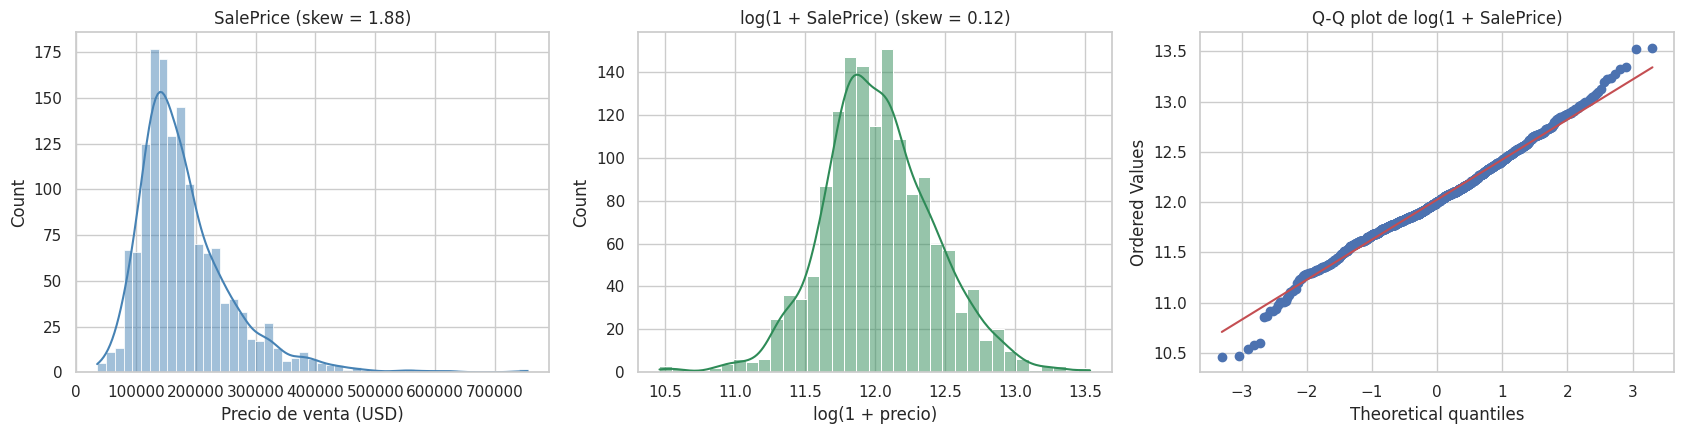

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(y, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice (skew = {y.skew():.2f})")
axes[0].set_xlabel("Precio de venta (USD)")

sns.histplot(np.log1p(y), kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log(1 + SalePrice) (skew = {np.log1p(y).skew():.2f})")
axes[1].set_xlabel("log(1 + precio)")

stats.probplot(np.log1p(y), plot=axes[2])
axes[2].set_title("Q-Q plot de log(1 + SalePrice)")

plt.tight_layout()
plt.savefig("figures/01_saleprice_distribucion.png", dpi=200, bbox_inches="tight")
plt.show()

**Observación:** `SalePrice` tiene asimetría positiva (cola larga de casas caras). La transformación logarítmica la acerca a una distribución normal y es la escala en la que Kaggle calcula el error (RMSE sobre el logaritmo del precio).

## 4. Datos faltantes

In [28]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tabla_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "porcentaje": (nulos / len(df) * 100).round(2),
    "tipo": df[nulos.index].dtypes.astype(str),
})
print("Columnas con nulos:", len(tabla_nulos))
tabla_nulos

Columnas con nulos: 19


,n_nulos,porcentaje,tipo
PoolQC,1453,99.52,object
MiscFeature,1406,96.30,object
Alley,1369,93.77,object
Fence,1179,80.75,object
FireplaceQu,690,47.26,object
LotFrontage,259,17.74,float64
GarageCond,81,5.55,object
GarageType,81,5.55,object
GarageYrBlt,81,5.55,float64
GarageFinish,81,5.55,object


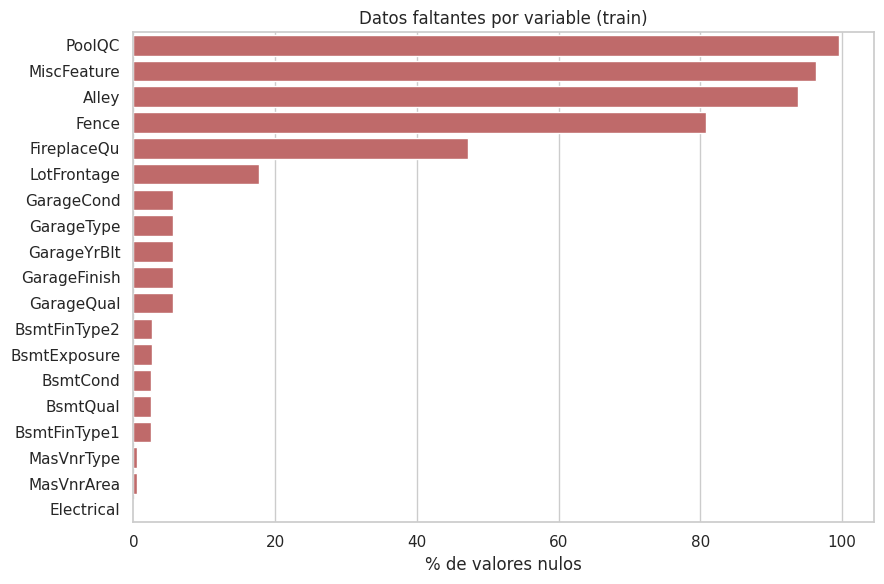

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=tabla_nulos["porcentaje"], y=tabla_nulos.index, color="indianred", ax=ax)
ax.set_xlabel("% de valores nulos"); ax.set_ylabel("")
ax.set_title("Datos faltantes por variable (train)")
plt.tight_layout()
plt.savefig("figures/02_nulos.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretación.** Según la documentación del dataset, en casi todas estas columnas `NA` significa *la vivienda no tiene esa característica*:

| Grupo | Columnas | Significado de `NA` |
|---|---|---|
| Piscina, callejón, cerca, varios | `PoolQC`, `Alley`, `Fence`, `MiscFeature` | No tiene |
| Chimenea | `FireplaceQu` | No tiene chimenea |
| Garaje | `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` | No tiene garaje |
| Sótano | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | No tiene sótano |

Datos **realmente perdidos**: `LotFrontage`, `MasVnrType`/`MasVnrArea` y `Electrical` (1 fila). Verifica esto con la celda siguiente.

In [30]:
# Comprobación: ¿los nulos de garaje coinciden con GarageArea == 0?
garage_null = df["GarageType"].isna()
print("Filas sin GarageType:", garage_null.sum())
print("De ellas, con GarageArea == 0:", (df.loc[garage_null, "GarageArea"] == 0).sum())

bsmt_null = df["BsmtQual"].isna()
print("Filas sin BsmtQual:", bsmt_null.sum())
print("De ellas, con TotalBsmtSF == 0:", (df.loc[bsmt_null, "TotalBsmtSF"] == 0).sum())

Filas sin GarageType: 81
De ellas, con GarageArea == 0: 81
Filas sin BsmtQual: 37
De ellas, con TotalBsmtSF == 0: 37


## 5. Correlaciones con `SalePrice`

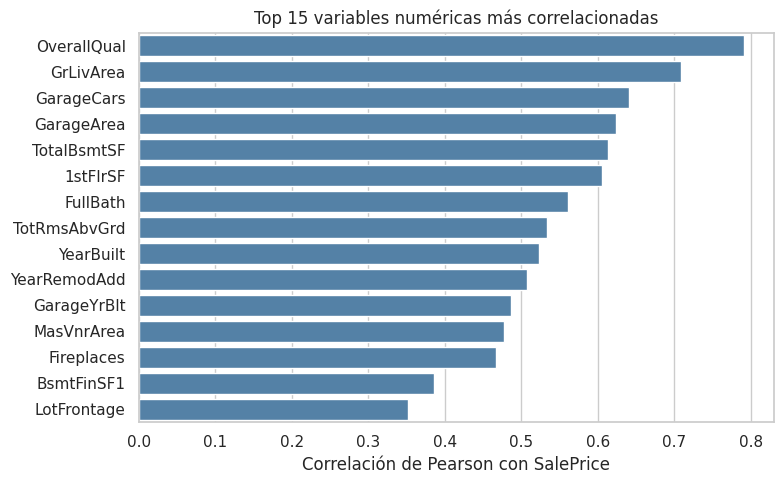

,correlación
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523
YearRemodAdd,0.507


In [31]:
num = df.select_dtypes(include="number").drop(columns="Id")
corr = num.corr()["SalePrice"].drop("SalePrice").sort_values(key=abs, ascending=False)

top = corr.head(15)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top.values, y=top.index, color="steelblue", ax=ax)
ax.set_xlabel("Correlación de Pearson con SalePrice"); ax.set_ylabel("")
ax.set_title("Top 15 variables numéricas más correlacionadas")
plt.tight_layout()
plt.savefig("figures/03_correlacion_top15.png", dpi=200, bbox_inches="tight")
plt.show()
corr.head(15).round(3).to_frame("correlación")

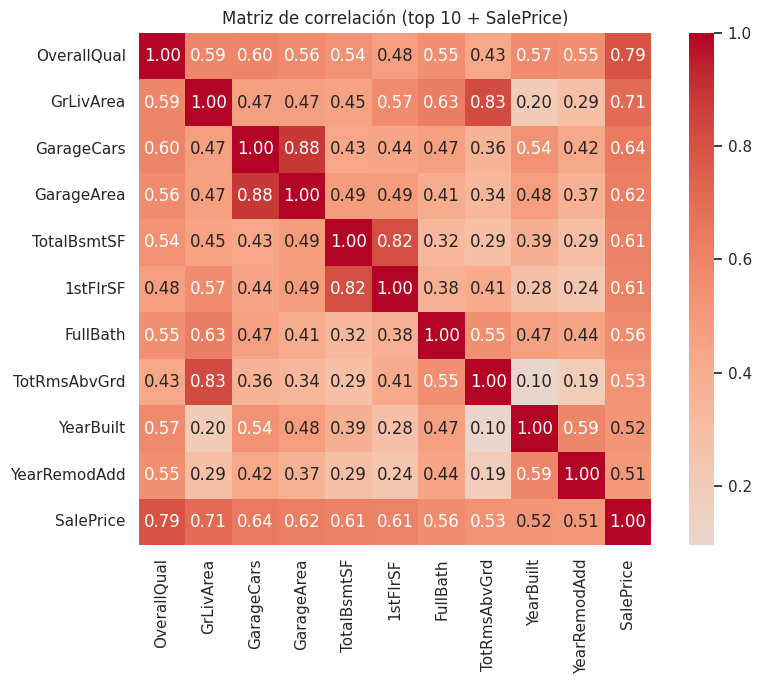

In [32]:
cols = corr.head(10).index.tolist() + ["SalePrice"]
plt.figure(figsize=(9, 7))
sns.heatmap(num[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación (top 10 + SalePrice)")
plt.tight_layout()
plt.savefig("figures/04_heatmap_correlacion.png", dpi=200, bbox_inches="tight")
plt.show()

**Multicolinealidad:** revisa pares muy correlacionados entre sí (p. ej. `GarageCars`–`GarageArea`, `TotalBsmtSF`–`1stFlrSF`, `GrLivArea`–`TotRmsAbvGrd`). Son candidatos a eliminar o a combinar, sobre todo para modelos lineales.

In [33]:
# Pares de predictores con |correlación| > 0.8
c = num.drop(columns="SalePrice").corr().abs()
pares = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
           .stack().sort_values(ascending=False))
pares[pares > 0.8].round(3)

,,0
GarageCars,GarageArea,0.882
YearBuilt,GarageYrBlt,0.826
GrLivArea,TotRmsAbvGrd,0.825
TotalBsmtSF,1stFlrSF,0.820


## 6. Relación de variables clave con el precio

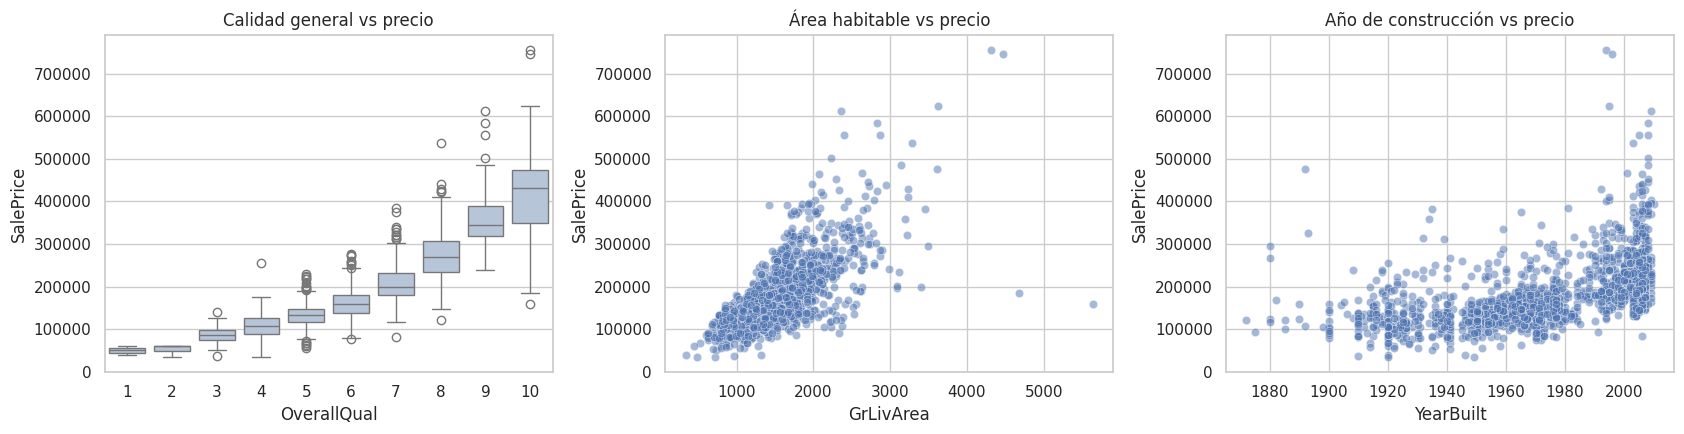

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[0], color="lightsteelblue")
axes[0].set_title("Calidad general vs precio")
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.5, ax=axes[1])
axes[1].set_title("Área habitable vs precio")
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice", alpha=0.5, ax=axes[2])
axes[2].set_title("Año de construcción vs precio")
plt.tight_layout()
plt.savefig("figures/05_variables_clave.png", dpi=200, bbox_inches="tight")
plt.show()

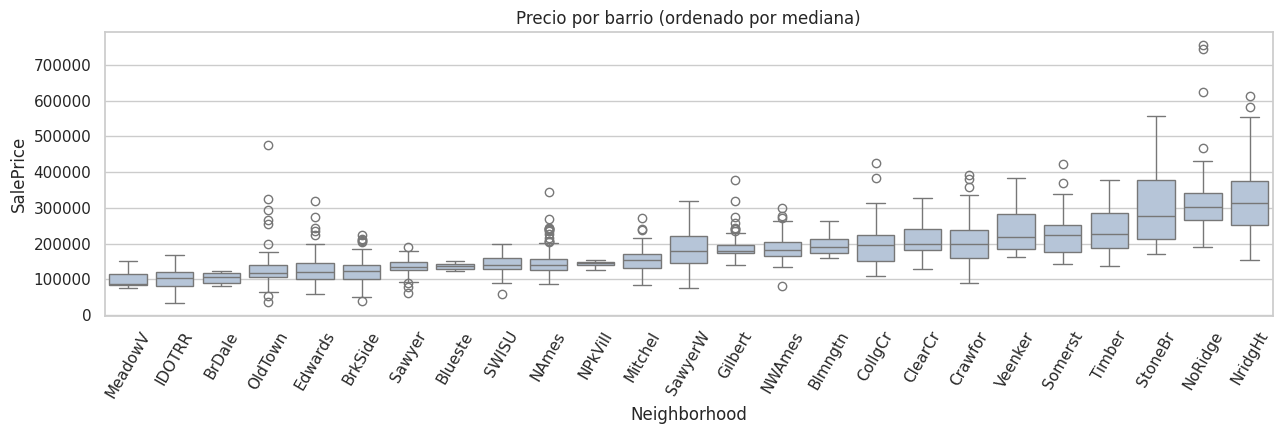

In [35]:
orden = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index
plt.figure(figsize=(13, 4.5))
sns.boxplot(data=df, x="Neighborhood", y="SalePrice", order=orden, color="lightsteelblue")
plt.xticks(rotation=60)
plt.title("Precio por barrio (ordenado por mediana)")
plt.tight_layout()
plt.savefig("figures/06_precio_por_barrio.png", dpi=200, bbox_inches="tight")
plt.show()

In [36]:
# ¿Garaje, remodelación y chimenea influyen? (las variables que motivan el problema)
comp = pd.DataFrame({
    "Con garaje": [df.loc[df.GarageArea > 0, "SalePrice"].median(), df.loc[df.GarageArea == 0, "SalePrice"].median()],
    "Remodelada": [df.loc[df.YearRemodAdd > df.YearBuilt, "SalePrice"].median(), df.loc[df.YearRemodAdd == df.YearBuilt, "SalePrice"].median()],
    "Con chimenea": [df.loc[df.Fireplaces > 0, "SalePrice"].median(), df.loc[df.Fireplaces == 0, "SalePrice"].median()],
}, index=["Sí (mediana)", "No (mediana)"]).T
comp

,Sí (mediana),No (mediana)
Con garaje,167500.0,100000.0
Remodelada,155000.0,170000.0
Con chimenea,191000.0,135000.0


## 7. Valores atípicos
Los casos con `GrLivArea` muy grande y precio bajo (conocidos en este dataset) son candidatos a eliminar antes de entrenar.

In [37]:
atipicos = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print("Candidatos a outlier:", len(atipicos))
atipicos[["Id", "GrLivArea", "SalePrice", "OverallQual", "Neighborhood", "SaleCondition"]]

Candidatos a outlier: 2


,Id,GrLivArea,SalePrice,OverallQual,Neighborhood,SaleCondition
523,524,4676,184750,10,Edwards,Partial
1298,1299,5642,160000,10,Edwards,Partial


## 8. Preprocesamiento: imputación y codificación
Implementa la estrategia descrita en el informe. **Todas las estadísticas de imputación se calculan solo con `train`** (al tener test, se reutilizan esos valores para evitar fuga de información).

In [38]:
data = df.copy()

# (i) NA = ausencia de la característica -> categoría "None"
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
for c in none_cols:
    data[c] = data[c].fillna("None")

# (ii) Numéricas asociadas a la ausencia -> 0
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars", "MasVnrArea",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath"]
for c in zero_cols:
    if c in data:
        data[c] = data[c].fillna(0)   # nota: GarageYrBlt = 0 indica 'sin garaje'

# (iii) LotFrontage -> mediana por barrio (calculada con train)
medianas_barrio = data.groupby("Neighborhood")["LotFrontage"].median()
data["LotFrontage"] = data["LotFrontage"].fillna(data["Neighborhood"].map(medianas_barrio))
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

# (iv) Resto (p. ej. Electrical) -> moda
for c in data.columns[data.isna().any()]:
    data[c] = data[c].fillna(data[c].mode()[0])

print("Nulos restantes:", int(data.isna().sum().sum()))

Nulos restantes: 0


In [39]:
# Numéricas que en realidad son categóricas
for c in ["MSSubClass", "MoSold", "YrSold"]:
    data[c] = data[c].astype(str)

# Ordinales de calidad/condición -> enteros que respetan el orden
escala = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ord_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
            "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
for c in ord_cols:
    data[c] = data[c].map(escala).astype(int)

# Nominales -> one-hot
cat_cols = data.select_dtypes(include="object").columns
data_enc = pd.get_dummies(data.drop(columns="Id"), columns=cat_cols, drop_first=True, dtype=int)

print("Variables ordinales codificadas:", len(ord_cols))
print("Variables nominales (one-hot):", len(cat_cols))
print("Forma final:", data_enc.shape)

Variables ordinales codificadas: 10
Variables nominales (one-hot): 36
Forma final: (1460, 256)


In [40]:
# Asimetría de predictores numéricos continuos (candidatos a log1p)
num_cols = [c for c in data.select_dtypes(include="number").columns if c not in ["Id", "SalePrice"] + ord_cols]
skew = data[num_cols].skew().sort_values(ascending=False)
skew[skew.abs() > 0.75].round(2).head(15).to_frame("skew")

,skew
MiscVal,24.48
PoolArea,14.83
LotArea,12.21
3SsnPorch,10.30
LowQualFinSF,9.01
KitchenAbvGr,4.49
BsmtFinSF2,4.26
ScreenPorch,4.12
BsmtHalfBath,4.10
EnclosedPorch,3.09


In [41]:
# Guardar el dataset preprocesado para la siguiente entrega
os.makedirs("data", exist_ok=True)
data_enc.to_csv("data/train_preprocesado.csv", index=False)

## 9. Definición de la aproximación de ML
- **Configuración:** aprendizaje supervisado, regresión. Entrada: 79 variables de la vivienda; salida: `SalePrice`.
- **Objetivo transformado:** `log1p(SalePrice)` para reducir la asimetría.
- **Modelos a comparar:** Ridge, Lasso, Elastic Net, Random Forest y Gradient Boosting/XGBoost.
- **Validación:** validación cruzada k-fold sobre train + conjunto de prueba de Kaggle.
- **Métrica:** RMSE sobre el logaritmo del precio (RMSLE), más $R^2$ y MAE.

## 10. Conclusiones
1. **Composición.** `train.csv` tiene 1460 viviendas y 81 columnas (Id, 79 variables explicativas y `SalePrice`): 38 numéricas (incluyendo `Id` y `SalePrice`) y 43 categóricas. No hay filas duplicadas.
2. **Variable objetivo.** `SalePrice` tiene media USD 180 921, mediana USD 163 000, mínimo USD 34 900 y máximo USD 755 000. Su asimetría (1.88) y curtosis (6.54) indican una cola larga hacia las viviendas caras, por lo que se modelará `log(1 + SalePrice)`.
3. **Datos faltantes.** 19 columnas tienen nulos. Las más afectadas son `PoolQC` (99.52 %), `MiscFeature` (96.30 %), `Alley` (93.77 %), `Fence` (80.75 %) y `FireplaceQu` (47.26 %), seguidas de `LotFrontage` (17.74 %), las variables de garaje (5.55 %) y de sótano (2.5 %). En casi todas, `NA` significa *ausencia de la característica*; solo `LotFrontage`, `MasVnrType`/`MasVnrArea` y `Electrical` son datos realmente perdidos.
4. **Correlaciones.** Las variables numéricas más asociadas al precio son `OverallQual` (0.791), `GrLivArea` (0.709), `GarageCars` (0.640), `GarageArea` (0.623), `TotalBsmtSF` (0.614) y `1stFlrSF` (0.606). El precio depende de la calidad y de muchas otras características, no solo del tamaño.
5. **Multicolinealidad.** Hay cuatro pares de predictores con correlación mayor a 0.8: `GarageCars`–`GarageArea` (0.882), `YearBuilt`–`GarageYrBlt` (0.826), `GrLivArea`–`TotRmsAbvGrd` (0.825) y `TotalBsmtSF`–`1stFlrSF` (0.820). Se tratarán en el modelado (selección o combinación de variables y regularización).
6. **Garaje, chimenea y remodelación.** Las viviendas con garaje tienen mediana de USD 167 500 frente a USD 100 000 sin garaje; con chimenea, USD 191 000 frente a USD 135 000. Las remodeladas tienen una mediana menor (USD 155 000) que las no remodeladas (USD 170 000), lo que se explica probablemente por confusión con la antigüedad de la vivienda; se analizará junto con el año de construcción.
7. **Valores atípicos.** Dos viviendas (`Id` 524 y 1299) tienen más de 4000 pies² habitables, calidad 10 y precio menor a USD 185 000; se eliminarán antes de entrenar.
8. **Preprocesamiento.** Tras la imputación no quedan nulos. Se codificaron 10 variables ordinales y 36 nominales (one-hot), y el conjunto resultante es de 1460 × 256 (255 predictores más `SalePrice`), guardado en `data/train_preprocesado.csv`.
